# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## 🧠 Antes de empezar: ¿qué es Deep Learning?

Hasta ahora hemos trabajado con modelos de *Machine Learning clásico*: regresión lineal, regresión logística, KNN, árboles, Random Forest, etc. **Deep Learning** es una rama del Machine Learning que usa un tipo concreto de modelo: las **redes neuronales artificiales con muchas capas** (de ahí lo de "deep", profundo).

### Intuición
Imagina una cadena de montaje. En cada estación (capa) entran datos, se transforman un poco, y salen hacia la siguiente estación. Al final, la última estación da la respuesta. Cada estación tiene unos "botones" (los **pesos**) que se ajustan automáticamente durante el entrenamiento para que la respuesta final sea lo más correcta posible.

### Definición plana
Una red neuronal es una **función matemática compuesta**: encadena multiplicaciones de matrices (pesos) y sumas (biases), intercaladas con funciones no lineales (las llamadas *funciones de activación*). Aprende ajustando los pesos para minimizar una función de error.

### Ejemplo numérico mínimo
Una neurona simple con dos entradas hace:

$$z = w_1 x_1 + w_2 x_2 + b$$

$$\text{salida} = f(z)$$

Si $x_1=2, x_2=3, w_1=0.5, w_2=-1, b=1$, entonces $z = 0.5 \cdot 2 + (-1) \cdot 3 + 1 = -1$. Si $f$ es ReLU (que devuelve $\max(0, z)$), la salida es $0$.

Una **red** apila muchas neuronas como esta, organizadas en capas, con miles o millones de pesos que se ajustan automáticamente.

### ¿Qué vamos a hacer en este notebook?
Vamos a entrenar una red para clasificar imágenes de ropa en 10 categorías (camiseta, pantalón, zapato, etc.). Cada imagen tiene 28×28 = 784 píxeles en escala de grises. La red recibirá esos 784 números y devolverá uno de 10 valores.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

### 📚 Las librerías que usamos
- **numpy**: trabajar con arrays numéricos (las imágenes son arrays).
- **pandas**: manejar datos tabulares (aquí lo usaremos poco).
- **matplotlib.pyplot**: dibujar gráficos e imágenes.
- **seaborn**: gráficos estadísticos más bonitos (heatmap para la matriz de confusión).
- **keras**: el API de alto nivel de TensorFlow para construir redes neuronales sin tener que programar todas las matemáticas internas.

In [1]:
import tensorflow as tf
print(tf.__version__)

2.16.2


In [2]:
# Importamos las librerías básicas para análisis numérico, manipulación de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos keras desde tensorflow: es el API que usaremos para construir y entrenar la red neuronal
from tensorflow import keras

In [3]:
# Obtenemos el objeto del dataset Fashion MNIST que viene preempaquetado en keras.
# Todavía no descargamos los datos, solo guardamos una referencia al "loader"
dataset = keras.datasets.fashion_mnist

# Llamamos a load_data() para que descargue (la primera vez) y devuelva el dataset.
# load_data() devuelve una tupla con dos tuplas: ((X_train, y_train), (X_test, y_test))
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [4]:
# Comprobamos qué hay dentro de la primera tupla devuelta por load_data().
# load_data()[0] es la tupla de entrenamiento (X_train, y_train), por eso esperamos longitud 2
len(dataset.load_data()[0])

2

### 📐 ¿Qué significa el `.shape`?
Cuando tenemos un array de NumPy, `.shape` devuelve sus dimensiones.

**Ejemplo numérico**: si `X_train.shape` es `(60000, 28, 28)`, significa que tenemos:
- 60000 imágenes
- cada una de 28 filas (alto)
- por 28 columnas (ancho)

Por su parte, `y_train.shape = (60000,)` significa: un único vector de 60000 etiquetas (números enteros del 0 al 9, uno por imagen).

In [5]:
# Hacemos el "unpacking" de las dos tuplas en cuatro variables.
# X_train, X_test contienen las imágenes; y_train, y_test contienen las etiquetas (0-9).
(X_train, y_train), (X_test, y_test) = dataset.load_data()

# Imprimimos las dimensiones para entender la estructura de los datos
print(X_train.shape)   # (n_train, 28, 28) -> imágenes de entrenamiento
print(X_test.shape)    # (n_test, 28, 28)  -> imágenes de test
print(y_train.shape)   # (n_train,)        -> etiquetas de entrenamiento
print(y_test.shape)    # (n_test,)         -> etiquetas de test

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr><td>0</td><td>T-shirt/top</td></tr>
  <tr><td>1</td><td>Trouser</td></tr>
  <tr><td>2</td><td>Pullover</td></tr>
  <tr><td>3</td><td>Dress</td></tr>
  <tr><td>4</td><td>Coat</td></tr>
  <tr><td>5</td><td>Sandal</td></tr>
  <tr><td>6</td><td>Shirt</td></tr>
  <tr><td>7</td><td>Sneaker</td></tr>
  <tr><td>8</td><td>Bag</td></tr>
  <tr><td>9</td><td>Ankle boot</td></tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [6]:
# Guardamos los nombres de las 10 clases en una lista, en el ORDEN exacto que corresponde a las etiquetas 0-9.
# Es decir: la posición 0 de la lista es la clase de la etiqueta 0, etc.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)  # debe ser 10

10

In [7]:
# Inspeccionamos las etiquetas: vemos que son números enteros entre 0 y 9
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

### 🔍 Cómo respondemos cada pregunta
- **Número de imágenes**: lo obtenemos con `X_train.shape[0]` (la primera dimensión es el nº de muestras).
- **Píxeles por imagen**: las dimensiones 2 y 3 del shape (28 × 28 = 784 píxeles).
- **Valores de los labels**: usamos `np.unique(y_train)` para ver qué etiquetas distintas existen.

In [8]:
# Número de imágenes en cada conjunto: usamos shape[0] que nos da la primera dimensión (cantidad de muestras)
print(f"Imágenes en train: {X_train.shape[0]}")
print(f"Imágenes en test:  {X_test.shape[0]}")

# Tamaño de cada imagen: las otras dos dimensiones del array nos dicen cuántos píxeles tiene cada imagen
print(f"Cada imagen mide: {X_train.shape[1]} x {X_train.shape[2]} = {X_train.shape[1]*X_train.shape[2]} píxeles")

# Valores únicos de los labels: con np.unique vemos qué etiquetas distintas aparecen en y_train
print(f"Valores únicos de las labels: {np.unique(y_train)}")

# Bonus: vemos también el rango de valores de los píxeles, lo necesitaremos justo después para escalar
print(f"Valor mínimo de píxel: {X_train.min()} | Valor máximo de píxel: {X_train.max()}")

Imágenes en train: 60000
Imágenes en test:  10000
Cada imagen mide: 28 x 28 = 784 píxeles
Valores únicos de las labels: [0 1 2 3 4 5 6 7 8 9]
Valor mínimo de píxel: 0 | Valor máximo de píxel: 255


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

### 🖼️ ¿Qué es `imshow`?
`plt.imshow(matriz)` toma una matriz 2D de números y la dibuja como una imagen, asignando un color a cada valor según un mapa de color (`cmap`).

**Ejemplo**: una matriz 3×3 con valores entre 0 y 255, donde 0 es negro y 255 es blanco, se vería como una mini-imagen en escala de grises.

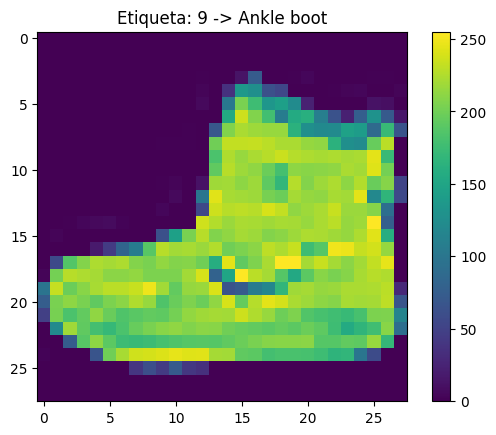

In [9]:
# Dibujamos la primera imagen del conjunto de entrenamiento (índice 0)
plt.figure()
plt.imshow(X_train[0])  # X_train[0] es una matriz 28x28 con valores 0-255
plt.colorbar()          # añadimos una barra de color para ver el rango de valores
plt.grid(False)

# Mostramos también qué clase es esta primera imagen, según su etiqueta y el class_names
plt.title(f"Etiqueta: {y_train[0]} -> {class_names[y_train[0]]}")
plt.show()

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

### 📏 ¿Por qué escalamos los píxeles dividiendo entre 255?

**Intuición**: las redes neuronales aprenden mejor cuando todas las entradas tienen rangos parecidos y pequeños. Si entran números grandes (0-255), los gradientes que se calculan durante el entrenamiento se vuelven inestables (muy grandes o muy pequeños) y la red tarda mucho más en aprender, o directamente no aprende.

**Definición plana**: en imágenes en escala de grises, cada píxel es un entero entre 0 (negro) y 255 (blanco). Si dividimos todo el array entre 255, obtenemos valores entre 0.0 y 1.0. A esto se le llama **normalización min-max** (cuando el mínimo es 0 y el máximo es 255 conocido a priori, basta con dividir).

**Ejemplo numérico**: un píxel con valor 128 → 128/255 ≈ 0.502. Un píxel negro 0 → 0.0. Un píxel blanco 255 → 1.0.

In [10]:
# Dividimos cada array de imágenes entre 255 para llevar los valores al rango [0, 1]
# Esto se aplica elemento a elemento sobre TODO el array (numpy lo hace automáticamente)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Comprobamos que ahora los valores van efectivamente de 0 a 1
print(f"Tras escalar - mínimo: {X_train.min()}, máximo: {X_train.max()}")

Tras escalar - mínimo: 0.0, máximo: 1.0


Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

### 🧩 Cómo dibujamos un grid de 25 imágenes
Vamos a crear una figura de 5×5 = 25 subplots con `plt.subplots`. En cada celda dibujamos una imagen con `imshow` y debajo añadimos el nombre de la clase con `xlabel`.

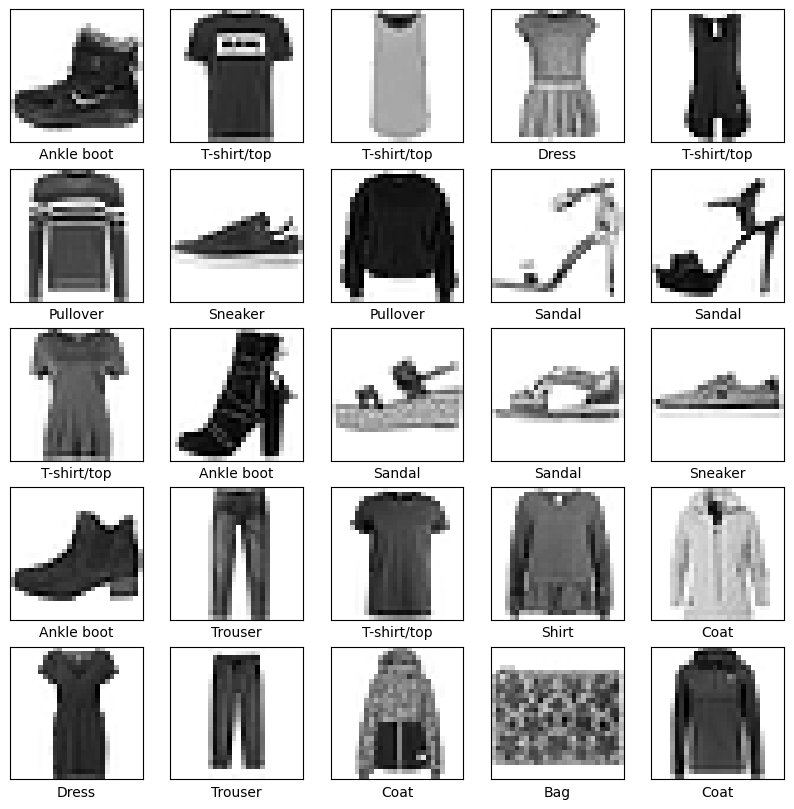

In [11]:
# Creamos una figura grande para que las imágenes se vean bien
plt.figure(figsize=(10,10))

# Recorremos las primeras 25 imágenes del set de entrenamiento
for i in range(25):
    # Cada subplot ocupa una posición en una rejilla 5x5; el índice i+1 va de 1 a 25
    plt.subplot(5, 5, i+1)
    
    # Quitamos los ticks de los ejes para que las imágenes queden limpias
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    # Dibujamos la imagen i en escala de grises (cmap='binary' = blanco-negro invertido)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    
    # Debajo de cada imagen ponemos el nombre de la clase correspondiente a su etiqueta
    plt.xlabel(class_names[y_train[i]])

plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### 🏗️ Anatomía de la red que vamos a construir

Vamos a usar un modelo **secuencial** (`keras.Sequential`): es una pila de capas, donde la salida de una capa es la entrada de la siguiente, sin ramificaciones.

Nuestra red tendrá tres capas:

**1. `Flatten(input_shape=(28, 28))` — capa de aplanado**
- *Intuición*: la red densa que viene después espera un vector (1D), no una matriz 2D. Hay que "desenrollar" la imagen 28×28 en una fila de 784 números.
- *Ejemplo*: si la matriz fuera 2×2 con valores `[[1,2],[3,4]]`, Flatten la convertiría en `[1,2,3,4]`.

**2. `Dense(128, activation='relu')` — capa oculta**
- *Definición*: una capa **densa** (también llamada *fully connected*) tiene cada una de sus neuronas conectada a TODAS las neuronas de la capa anterior.
- *128 neuronas*: es un hiperparámetro que elegimos. Más neuronas = más capacidad para aprender patrones complejos, pero también más riesgo de sobreajuste y más coste computacional. 128 es un valor estándar para empezar.
- *ReLU (Rectified Linear Unit)*: es la función de activación. Hace `max(0, x)`: si la entrada es negativa, devuelve 0; si es positiva, la deja igual.
  - *Ejemplo*: `ReLU(-3) = 0`, `ReLU(2.5) = 2.5`. Aporta no-linealidad, que es lo que permite a la red aprender relaciones complejas (sin activaciones no lineales, una red de 100 capas se reduciría matemáticamente a una sola operación lineal).

**3. `Dense(10, activation='softmax')` — capa de salida**
- *10 neuronas*: una por clase (T-shirt, Trouser, ...).
- *Softmax*: convierte un vector de números cualesquiera en un vector de **probabilidades que suman 1**. La neurona con la probabilidad más alta es la clase predicha.
  - *Ejemplo*: si la salida antes de softmax es `[2.0, 1.0, 0.1]`, softmax la convierte en aproximadamente `[0.66, 0.24, 0.10]` (suman 1).

### Configurar las Capas
Construye todas las capas del modelo.

In [12]:
# Construimos un modelo secuencial: una pila lineal de capas
model = keras.Sequential([
    # Capa 1: aplanamos la imagen 28x28 en un vector de 784 valores.
    # input_shape le dice a la red el tamaño de cada muestra de entrada
    keras.layers.Flatten(input_shape=(28, 28)),
    
    # Capa 2: capa oculta densa con 128 neuronas y activación ReLU.
    # Aquí es donde la red aprende patrones internos de las imágenes
    keras.layers.Dense(128, activation='relu'),
    
    # Capa 3: capa de salida con 10 neuronas (una por clase) y softmax,
    # que convierte las salidas en probabilidades que suman 1
    keras.layers.Dense(10, activation='softmax')
])

# Imprimimos un resumen para verificar el número de parámetros entrenables
model.summary()

/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-05-06 10:35:13.428617: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-06 10:35:13.428670: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-06 10:35:13.428673: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-06 10:35:13.428703: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-06 10:35:13.428713: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow devic

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

### ⚙️ Las tres piezas del compile

**1. Loss function (función de pérdida)**
- *Intuición*: un único número que indica cómo de mal lo está haciendo el modelo. Cuanto más alto, peor; el entrenamiento intenta bajarlo.
- *`sparse_categorical_crossentropy`*: es la pérdida estándar para clasificación multiclase **cuando las etiquetas son enteros** (0, 1, 2, ..., 9). "Sparse" significa precisamente eso: no hace falta convertir las etiquetas a one-hot.
  - *Ejemplo*: si la verdad es la clase 3 y el modelo predice probabilidades `[0.1, 0.0, 0.05, 0.7, 0.05, 0.0, 0.0, 0.05, 0.05, 0.0]`, la pérdida será $-\log(0.7) \approx 0.36$ — pequeña, porque acertó con confianza. Si en cambio predice 0.1 para la clase 3, la pérdida será $-\log(0.1) \approx 2.30$ — mayor.

**2. Optimizer**
- *Intuición*: el algoritmo que ajusta los pesos para bajar la pérdida. Imagínalo como alguien con los ojos vendados que, en cada paso, palpa la pendiente del terreno y baja por la dirección de máxima caída.
- *`adam`*: una variante muy popular del gradiente descendente que adapta la velocidad de aprendizaje automáticamente para cada parámetro. Es el optimizador por defecto que casi siempre funciona bien.

**3. Metrics**
- *Intuición*: lo que queremos *vigilar* mientras entrena, sin que afecte al aprendizaje (la loss sí lo afecta).
- *`accuracy`*: porcentaje de predicciones correctas. Si de 100 imágenes acierta 87, accuracy = 0.87.

In [13]:
# Compilamos el modelo: le decimos cómo va a aprender (optimizer), qué error minimizar (loss)
# y qué métricas queremos vigilar durante el entrenamiento (metrics)
model.compile(
    optimizer='adam',                            # algoritmo que actualiza los pesos en cada paso
    loss='sparse_categorical_crossentropy',      # pérdida para clasificación multiclase con labels enteros
    metrics=['accuracy']                         # vigilamos el porcentaje de aciertos
)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

### 🔁 ¿Qué es un *epoch* y qué hace `fit`?

**Epoch**: una pasada completa por TODOS los datos de entrenamiento. Si tenemos 60.000 imágenes y entrenamos 10 epochs, el modelo "verá" cada imagen 10 veces.

**`model.fit(X, y, epochs=N)`** hace internamente, para cada epoch:
1. Toma un mini-lote de imágenes (por defecto 32).
2. Predice y calcula la loss.
3. Calcula los gradientes (cómo cambia la loss respecto a cada peso).
4. Ajusta los pesos un pequeño paso en la dirección que reduce la loss.
5. Repite con el siguiente mini-lote hasta agotar el dataset.

**Ejemplo numérico**: 60.000 imágenes / batch_size 32 ≈ 1875 pasos por epoch. En 10 epochs, son ~18.750 actualizaciones de pesos.

In [14]:
# -----------------------------------------------------------------------
# NOTA SOBRE TIEMPOS: entrenar con 60.000 imágenes en CPU tarda ~8 min.
# Para que veas el progreso en tiempo real usamos verbose=1.
# Si tu máquina va lenta, cambia X_train por X_train[:10000] y
# y_train por y_train[:10000] para entrenar solo con 10.000 imágenes
# y tardar ~1 min. Los resultados serán un poco peores pero funciona igual.
# -----------------------------------------------------------------------

# Entrenamos el modelo. verbose=1 muestra la barra de progreso en cada epoch
history = model.fit(X_train, y_train, epochs=10, verbose=1)

Epoch 1/10


2026-05-06 10:35:14.587027: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8113 - loss: 0.5449
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8384 - loss: 0.4679
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8404 - loss: 0.4631
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8429 - loss: 0.4594
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8434 - loss: 0.4612
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8404 - loss: 0.4737
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8400 - loss: 0.4793
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8404 - loss: 0.4789
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8398 - loss: 0.4869
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8377 - loss: 0.4957


## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

### 🎯 ¿Por qué evaluamos en test y no en train?
El conjunto de **test** son datos que el modelo NUNCA ha visto durante el entrenamiento. La accuracy en test es lo que mide la **capacidad de generalización** del modelo a datos nuevos.

Si vemos que la accuracy en train es muy alta (p. ej. 0.99) pero en test es baja (p. ej. 0.85), eso es **sobreajuste (overfitting)**: el modelo ha memorizado el train pero no generaliza.

In [15]:
# Evaluamos el modelo con el conjunto de test.
# evaluate() devuelve la loss y las métricas que pusimos en compile (accuracy)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"\nLoss en test:     {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")  # nos dice qué porcentaje de imágenes nuevas clasifica bien

313/313 - 1s - 5ms/step - accuracy: 0.8156 - loss: 0.6006

Loss en test:     0.6006
Accuracy en test: 0.8156


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

### 🔮 ¿Qué nos devuelve `predict`?
`model.predict(X)` devuelve, para cada imagen, un vector de 10 probabilidades (una por clase). La clase predicha es la posición con probabilidad más alta, que obtenemos con `np.argmax`.

**Ejemplo**: si la salida para una imagen es `[0.01, 0.02, 0.85, 0.03, 0.01, 0.02, 0.01, 0.02, 0.02, 0.01]`, el modelo está 85% seguro de que es la clase 2 (Pullover).

In [16]:
# Pedimos al modelo que prediga las clases de TODAS las imágenes de test
y_pred = model.predict(X_test)

# y_pred tiene shape (n_test, 10): para cada imagen, 10 probabilidades
print(f"Shape de y_pred: {y_pred.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Shape de y_pred: (10000, 10)


El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [17]:
# Vemos las 10 probabilidades que el modelo asigna a la primera imagen de test
y_pred[0]

array([2.1132675e-10, 1.0334643e-14, 3.9278034e-09, 1.5022464e-09,
       9.6544195e-10, 2.9331639e-02, 3.2405215e-08, 1.2388721e-02,
       6.5157423e-05, 9.5821446e-01], dtype=float32)

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [18]:
# np.argmax devuelve el ÍNDICE del valor más alto del array. Ese índice es la clase predicha.
clase_predicha = np.argmax(y_pred[0])
print(f"Clase predicha (índice): {clase_predicha}")
print(f"Nombre de la clase predicha: {class_names[clase_predicha]}")
print(f"Etiqueta verdadera (índice): {y_test[0]}")
print(f"Nombre de la clase verdadera: {class_names[y_test[0]]}")

Clase predicha (índice): 9
Nombre de la clase predicha: Ankle boot
Etiqueta verdadera (índice): 9
Nombre de la clase verdadera: Ankle boot


In [19]:
# Estas dos funciones auxiliares nos las dan ya hechas: dibujan una imagen con su predicción
# y un gráfico de barras con las 10 probabilidades respectivamente.
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

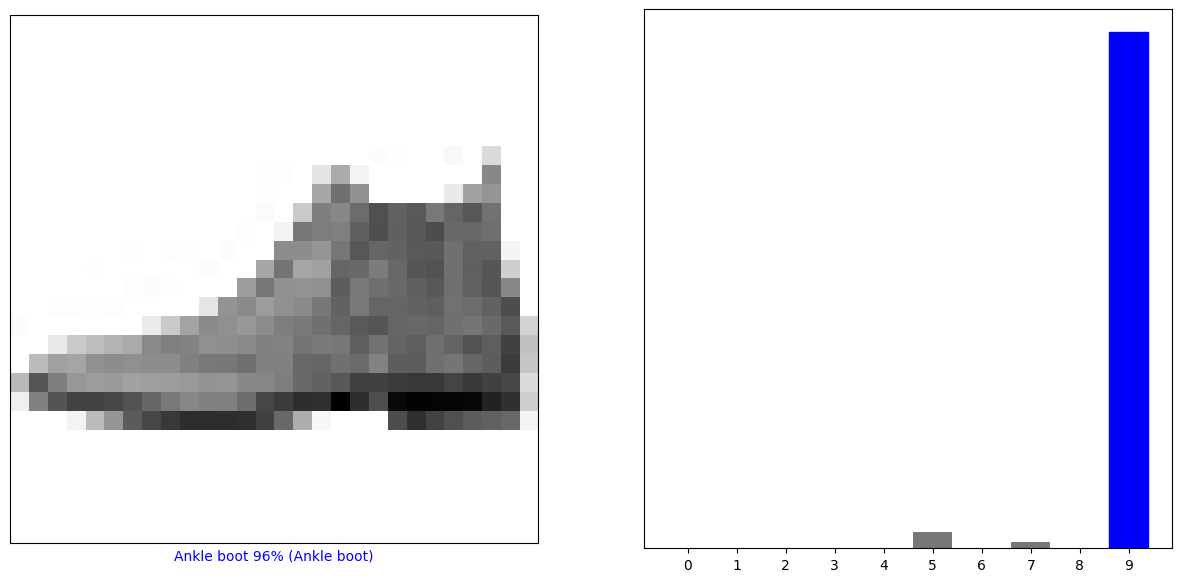

In [20]:
# Visualizamos la primera imagen de test junto con el array de probabilidades que predijo el modelo
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

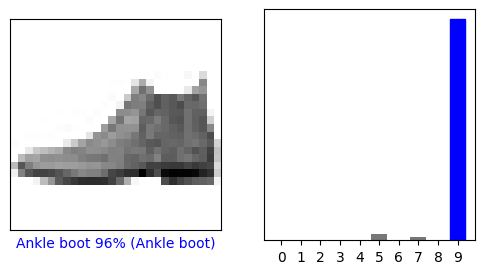

In [21]:
# Visualizamos la imagen [0] con sus 10 probabilidades en formato de barras
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i],  y_test)
plt.show()

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

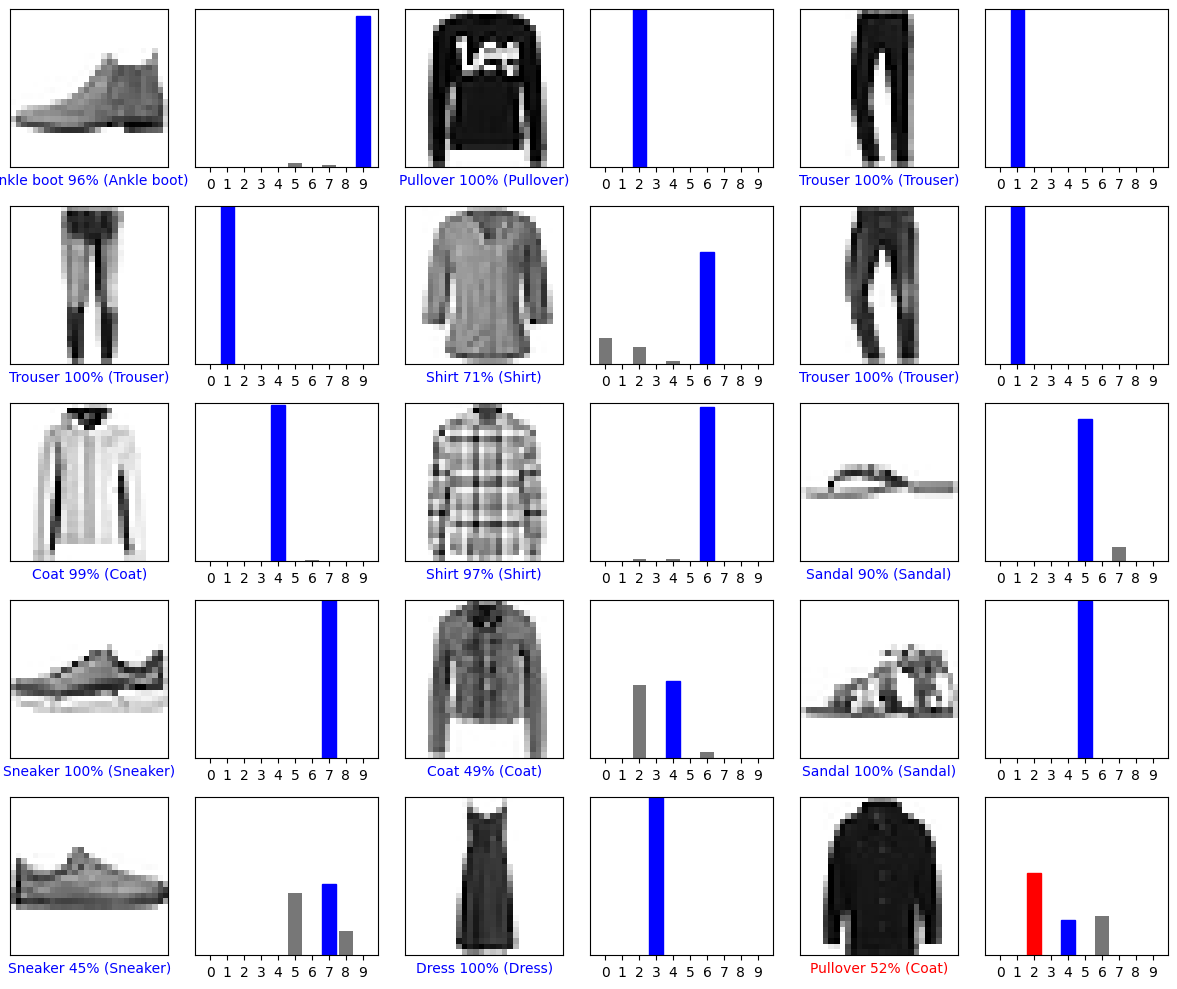

In [22]:
# Dibujamos las primeras 15 imágenes de test con sus predicciones (5 filas x 3 imágenes por fila).
# Cada imagen ocupa DOS subplots: uno con la imagen y otro con sus probabilidades de barras
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    # Subplot impar: la imagen con su predicción
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_pred[i], y_test, X_test)
    
    # Subplot par: el array de probabilidades en barras
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_pred[i], y_test)

plt.tight_layout()
plt.show()

Evalúa tu modelo con una matriz de confusión e interprétala.

### 🔢 ¿Qué es una matriz de confusión?

**Intuición**: una tabla cuadrada donde las filas son la clase REAL y las columnas son la clase PREDICHA. Cada celda dice cuántas imágenes de la clase real X fueron clasificadas como Y. La **diagonal** son los aciertos (real=predicho); todo lo demás son errores.

**Ejemplo numérico** (con 3 clases):

|              | Pred Gato | Pred Perro | Pred Conejo |
|--------------|-----------|------------|-------------|
| Real Gato    | 30        | 2          | 1           |
| Real Perro   | 4         | 25         | 0           |
| Real Conejo  | 0         | 1          | 28          |

Aquí el modelo clasificó correctamente 30 gatos, 25 perros y 28 conejos. Confundió 4 perros con gatos (fila Perro, columna Gato), etc.

**Para qué sirve**: nos ayuda a ver QUÉ clases se confunden entre sí. Si vemos que las camisas se confunden mucho con las camisetas, sabemos que esa frontera es difícil para el modelo.

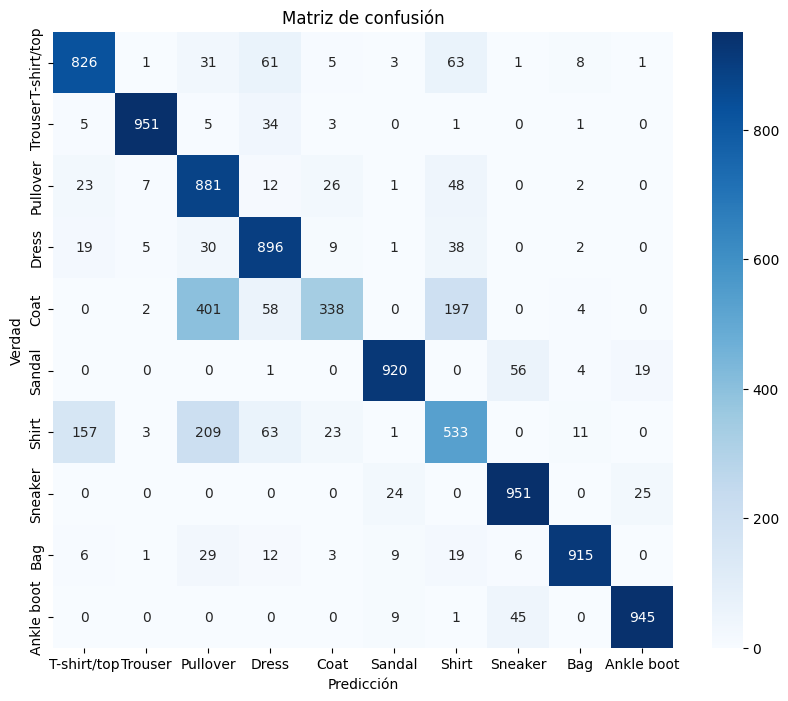

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.83      0.81      1000
     Trouser       0.98      0.95      0.97      1000
    Pullover       0.56      0.88      0.68      1000
       Dress       0.79      0.90      0.84      1000
        Coat       0.83      0.34      0.48      1000
      Sandal       0.95      0.92      0.93      1000
       Shirt       0.59      0.53      0.56      1000
     Sneaker       0.90      0.95      0.92      1000
         Bag       0.97      0.92      0.94      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.81     10000
weighted avg       0.83      0.82      0.81     10000



In [23]:
# Importamos la función de scikit-learn que calcula la matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report

# Convertimos las probabilidades en etiquetas predichas tomando el argmax de cada fila
y_pred_labels = np.argmax(y_pred, axis=1)

# Calculamos la matriz de confusión: filas = clase real, columnas = clase predicha
cm = confusion_matrix(y_test, y_pred_labels)

# Dibujamos la matriz como un heatmap para verla más claro
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,            # mostramos los números dentro de cada celda
    fmt='d',               # los números son enteros
    cmap='Blues',          # paleta de colores
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicción')
plt.ylabel('Verdad')
plt.title('Matriz de confusión')
plt.show()

# También imprimimos el classification_report para tener precision/recall/F1 por clase
print(classification_report(y_test, y_pred_labels, target_names=class_names))

### 📋 Cómo interpretamos la matriz
1. **La diagonal** (de arriba-izquierda a abajo-derecha) son los aciertos: cuanto más oscura, mejor.
2. **Casillas fuera de la diagonal con números altos** son las confusiones más típicas. En Fashion-MNIST suele pasar que:
   - **Shirt (6)** se confunde con **T-shirt/top (0)**, **Pullover (2)** y **Coat (4)** — son todos prendas de la parte superior del cuerpo, parecidas en silueta a baja resolución.
   - Los zapatos (Sandal 5, Sneaker 7, Ankle boot 9) son los más fáciles porque tienen siluetas muy distintas.
3. **Recall por clase**: la suma de cada fila es el total de imágenes reales de esa clase. El acierto en la diagonal dividido entre esa suma da el recall (qué fracción de esa clase identificamos correctamente).
4. **Precision por clase**: la suma de cada columna es el total de veces que el modelo predijo esa clase. El acierto en la diagonal dividido por esa suma da la precision (cuando predigo X, qué fracción de las veces acierto).

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

### 📦 ¿Por qué necesitamos `np.expand_dims`?
El modelo siempre espera un *batch* (lote) de imágenes, aunque sea de tamaño 1. Es decir, espera shape `(N, 28, 28)`, no `(28, 28)`.

`np.expand_dims(img, 0)` añade una dimensión al principio del array, convirtiendo `(28, 28)` en `(1, 28, 28)` — un "lote" de una sola imagen.

**Ejemplo**: array `[[1,2],[3,4]]` con shape `(2,2)` se convierte en `[[[1,2],[3,4]]]` con shape `(1,2,2)`.

In [24]:
# Cogemos una sola imagen del conjunto de test, por ejemplo la primera
img = X_test[0]
print(f"Shape original de la imagen: {img.shape}")  # (28, 28)

# Añadimos una dimensión al principio para convertirla en un "lote" de tamaño 1
img_batch = np.expand_dims(img, 0)
print(f"Shape tras expand_dims: {img_batch.shape}")  # (1, 28, 28)

# Predecimos sobre esa única imagen. La salida tendrá shape (1, 10): un vector de 10 probabilidades
prediccion_unica = model.predict(img_batch)
print(f"Probabilidades predichas: {prediccion_unica}")

# Tomamos el argmax para saber la clase predicha
clase = np.argmax(prediccion_unica[0])
print(f"\nClase predicha: {clase} -> {class_names[clase]}")
print(f"Clase verdadera: {y_test[0]} -> {class_names[y_test[0]]}")
print(f"Confianza: {100*np.max(prediccion_unica[0]):.2f}%")

Shape original de la imagen: (28, 28)
Shape tras expand_dims: (1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
Probabilidades predichas: [[2.1132517e-10 1.0334565e-14 3.9277888e-09 1.5022351e-09 9.6544206e-10
  2.9331446e-02 3.2405094e-08 1.2388681e-02 6.5157175e-05 9.5821458e-01]]

Clase predicha: 9 -> Ankle boot
Clase verdadera: 9 -> Ankle boot
Confianza: 95.82%
